In [ ]:
from google.colab import userdata
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

!pip install -q kaggle
!kaggle datasets download -d maharshipandya/-spotify-tracks-dataset -p /content/data --unzip
!kaggle datasets download -d rodolfofigueroa/spotify-12m-songs -p /content/data --unzip
!ls /content/data

Dataset URL: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset
License(s): ODbL-1.0
100% 8.17M/8.17M [00:00<00:00, 169MB/s]

Dataset URL: https://www.kaggle.com/datasets/rodolfofigueroa/spotify-12m-songs
License(s): unknown
100% 97.4M/97.4M [00:00<00:00, 198MB/s]

dataset.csv  tracks_features.csv


In [ ]:
import pandas as pd
import numpy as np

df_small = pd.read_csv('/content/data/dataset.csv')
df_large = pd.read_csv('/content/data/tracks_features.csv')

print(df_small.shape, df_large.shape)

(114000, 21) (1204025, 24)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Merge (needed later for temporal-drift experiment)
merged = df_small.merge(
    df_large[['id', 'year', 'release_date']],
    left_on='track_id', right_on='id', how='inner'
)

# Clean main dataset
df_clean = df_small.dropna(subset=['artists', 'album_name', 'track_name']).copy()
df_clean['is_hit'] = (df_clean['popularity'] >= 50).astype(int)

# Leakage-safe train/test split
train_df, test_df = train_test_split(
    df_clean, test_size=0.2, random_state=42, stratify=df_clean['track_genre']
)

# Artist popularity history — computed from TRAIN ONLY (no leakage)
artist_pop_map = train_df.groupby('artists')['popularity'].mean()
global_mean = train_df['popularity'].mean()
train_df['artist_avg_popularity'] = train_df['artists'].map(artist_pop_map)
test_df['artist_avg_popularity'] = test_df['artists'].map(artist_pop_map).fillna(global_mean)

# Genre encoding
le_genre = LabelEncoder()
train_df['genre_encoded'] = le_genre.fit_transform(train_df['track_genre'])
test_df['genre_encoded'] = test_df['track_genre'].map(
    dict(zip(le_genre.classes_, le_genre.transform(le_genre.classes_)))
)

feature_cols = [
    'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
    'time_signature', 'duration_ms', 'explicit',
    'artist_avg_popularity', 'genre_encoded'
]

X_train = train_df[feature_cols].copy()
X_train['explicit'] = X_train['explicit'].astype(int)
y_train_reg = train_df['popularity']
y_train_clf = train_df['is_hit']

X_test = test_df[feature_cols].copy()
X_test['explicit'] = X_test['explicit'].astype(int)
y_test_reg = test_df['popularity']
y_test_clf = test_df['is_hit']

print("Train/Test:", X_train.shape, X_test.shape)
print("Merged (for drift):", merged.shape)

Train/Test: (91199, 16) (22800, 16)
Merged (for drift): (6041, 24)


In [ ]:
!pip install -q lightgbm xgboost catboost

import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

results = {}

def evaluate(name, reg_model, clf_model):
    y_pred_reg = reg_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    mae = mean_absolute_error(y_test_reg, y_pred_reg)
    r2 = r2_score(y_test_reg, y_pred_reg)
    y_pred_clf = clf_model.predict(X_test)
    y_pred_proba = clf_model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test_clf, y_pred_clf)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test_clf, y_pred_clf, average='macro')
    auc = roc_auc_score(y_test_clf, y_pred_proba)
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2,
                      'Accuracy': acc, 'Precision': precision, 'Recall': recall, 'F1': f1, 'AUC': auc}
    print(f"=== {name} ===")
    print(f"Regression -> RMSE: {rmse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}")
    print(f"Classification -> Acc: {acc:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}")
    print()

lgb_reg = lgb.LGBMRegressor(random_state=42, n_estimators=200)
lgb_reg.fit(X_train, y_train_reg)
lgb_clf = lgb.LGBMClassifier(random_state=42, n_estimators=200, class_weight='balanced')
lgb_clf.fit(X_train, y_train_clf)
evaluate('LightGBM', lgb_reg, lgb_clf)

rf_reg = RandomForestRegressor(random_state=42, n_estimators=200, n_jobs=-1)
rf_reg.fit(X_train, y_train_reg)
rf_clf = RandomForestClassifier(random_state=42, n_estimators=200, n_jobs=-1, class_weight='balanced')
rf_clf.fit(X_train, y_train_clf)
evaluate('RandomForest', rf_reg, rf_clf)

xgb_reg = xgb.XGBRegressor(random_state=42, n_estimators=200)
xgb_reg.fit(X_train, y_train_reg)
scale_pos_weight = (y_train_clf == 0).sum() / (y_train_clf == 1).sum()
xgb_clf = xgb.XGBClassifier(random_state=42, n_estimators=200, scale_pos_weight=scale_pos_weight)
xgb_clf.fit(X_train, y_train_clf)
evaluate('XGBoost', xgb_reg, xgb_clf)

cat_reg = cb.CatBoostRegressor(random_state=42, iterations=200, verbose=0)
cat_reg.fit(X_train, y_train_reg)
cat_clf = cb.CatBoostClassifier(random_state=42, iterations=200, verbose=0, auto_class_weights='Balanced')
cat_clf.fit(X_train, y_train_clf)
evaluate('CatBoost', cat_reg, cat_clf)

results_df = pd.DataFrame(results).T
print(results_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2940
[LightGBM] [Info] Number of data points in the train set: 91199, number of used features: 16
[LightGBM] [Info] Start training from score 33.260255
[LightGBM] [Info] Number of positive: 23489, number of negative: 67710
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006458 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2940
[LightGBM] [Info] Number of data points in the train set: 91199, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
=== LightGBM ===
Regression -> RMSE: 14.491, MAE: 8.981, R²: 0.577
Classification -> Acc: 0.855, Pr

In [ ]:
import joblib
joblib.dump(rf_reg, 'rf_reg.pkl')
joblib.dump(rf_clf, 'rf_clf.pkl')
joblib.dump(xgb_reg, 'xgb_reg.pkl')
print("Models saved.")

Models saved.


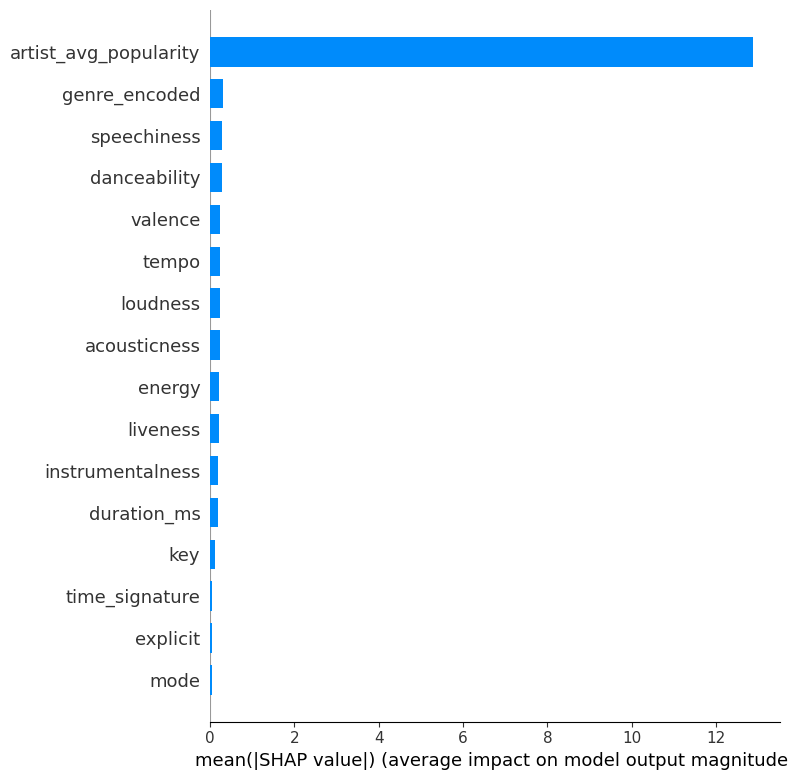

R² WITH artist feature: 0.652 (approx, from Cell 4)
R² WITHOUT artist feature: 0.525


In [ ]:
import shap
import matplotlib.pyplot as plt

shap_sample = X_test.sample(100, random_state=42)
explainer = shap.TreeExplainer(rf_reg)
shap_values = explainer.shap_values(shap_sample)
shap.summary_plot(shap_values, shap_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('/content/shap_global_importance.png', dpi=150)
plt.show()

# Ablation: quantify how much artist_avg_popularity alone contributes
feature_cols_ablated = [c for c in feature_cols if c != 'artist_avg_popularity']
X_train_abl = train_df[feature_cols_ablated].copy()
X_train_abl['explicit'] = X_train_abl['explicit'].astype(int)
X_test_abl = test_df[feature_cols_ablated].copy()
X_test_abl['explicit'] = X_test_abl['explicit'].astype(int)

rf_reg_abl = RandomForestRegressor(random_state=42, n_estimators=200, n_jobs=-1)
rf_reg_abl.fit(X_train_abl, y_train_reg)
r2_abl = r2_score(y_test_reg, rf_reg_abl.predict(X_test_abl))
print(f"R² WITH artist feature: 0.652 (approx, from Cell 4)")
print(f"R² WITHOUT artist feature: {r2_abl:.3f}")

In [ ]:
genre_counts = train_df['track_genre'].value_counts()
genres_to_test = genre_counts[genre_counts >= 500].index[:8]

genre_results = {}
for genre in genres_to_test:
    train_g = train_df[train_df['track_genre'] == genre]
    test_g = test_df[test_df['track_genre'] == genre]
    X_train_g = train_g[feature_cols].copy(); X_train_g['explicit'] = X_train_g['explicit'].astype(int)
    y_train_g = train_g['popularity']
    X_test_g = test_g[feature_cols].copy(); X_test_g['explicit'] = X_test_g['explicit'].astype(int)
    y_test_g = test_g['popularity']

    rf_g = RandomForestRegressor(random_state=42, n_estimators=200, n_jobs=-1)
    rf_g.fit(X_train_g, y_train_g)
    r2_g = r2_score(y_test_g, rf_g.predict(X_test_g))
    r2_global_on_g = r2_score(y_test_g, rf_reg.predict(X_test_g))
    genre_results[genre] = {'n_train': len(train_g), 'R2_genre_specific': r2_g,
                             'R2_global_model': r2_global_on_g, 'difference': r2_g - r2_global_on_g}

genre_results_df = pd.DataFrame(genre_results).T
print(genre_results_df)

                   n_train  R2_genre_specific  R2_global_model  difference
singer-songwriter    800.0           0.467545         0.796902   -0.329357
afrobeat             800.0           0.148409         0.127645    0.020764
mpb                  800.0           0.233482         0.628820   -0.395338
hard-rock            800.0           0.258459         0.590696   -0.332236
bluegrass            800.0          -0.260810        -0.272109    0.011300
forro                800.0           0.003471        -0.233469    0.236940
party                800.0           0.245349         0.271385   -0.026035
house                800.0           0.346941         0.528046   -0.181104


In [ ]:
merged_clean = merged.dropna(subset=['artists', 'album_name', 'track_name', 'year']).copy()
merged_clean['is_hit'] = (merged_clean['popularity'] >= 50).astype(int)

train_drift = merged_clean[(merged_clean['year'] >= 2010) & (merged_clean['year'] <= 2016)].copy()
test_drift = merged_clean[(merged_clean['year'] >= 2017) & (merged_clean['year'] <= 2020)].copy()

feature_cols_drift = [c for c in feature_cols if c != 'artist_avg_popularity']

le_genre_drift = LabelEncoder()
train_drift['genre_encoded'] = le_genre_drift.fit_transform(train_drift['track_genre'])
test_drift['genre_encoded'] = test_drift['track_genre'].map(
    dict(zip(le_genre_drift.classes_, le_genre_drift.transform(le_genre_drift.classes_)))
).fillna(-1)

X_train_drift = train_drift[feature_cols_drift].copy(); X_train_drift['explicit'] = X_train_drift['explicit'].astype(int)
y_train_drift = train_drift['popularity']
X_test_drift = test_drift[feature_cols_drift].copy(); X_test_drift['explicit'] = X_test_drift['explicit'].astype(int)
y_test_drift = test_drift['popularity']

rf_drift = RandomForestRegressor(random_state=42, n_estimators=200, n_jobs=-1)
rf_drift.fit(X_train_drift, y_train_drift)
r2_drift = r2_score(y_test_drift, rf_drift.predict(X_test_drift))

train_same, test_same = train_test_split(test_drift, test_size=0.3, random_state=42)
X_train_same = train_same[feature_cols_drift].copy(); X_train_same['explicit'] = X_train_same['explicit'].astype(int)
X_test_same = test_same[feature_cols_drift].copy(); X_test_same['explicit'] = X_test_same['explicit'].astype(int)
rf_same = RandomForestRegressor(random_state=42, n_estimators=200, n_jobs=-1)
rf_same.fit(X_train_same, train_same['popularity'])
r2_same = r2_score(test_same['popularity'], rf_same.predict(X_test_same))

print(f"Cross-era R² (train 2010-16 -> test 2017-20): {r2_drift:.3f}")
print(f"Same-era R² (train+test within 2017-20):       {r2_same:.3f}")
print(f"Drift gap: {r2_same - r2_drift:.3f}")

Cross-era R² (train 2010-16 -> test 2017-20): 0.240
Same-era R² (train+test within 2017-20):       0.616
Drift gap: 0.376


In [ ]:
import joblib
joblib.dump(rf_reg, 'rf_reg.pkl')
demo_df = pd.concat([train_df, test_df])[['track_name', 'artists', 'track_genre', 'popularity'] + feature_cols]
demo_df.to_csv('dataset_clean.csv', index=False)
print("Demo files saved.")
!ls -la rf_reg.pkl dataset_clean.csv

Demo files saved.
-rw-r--r-- 1 root root  15936231 Aug 10 21:39 dataset_clean.csv
-rw-r--r-- 1 root root 932523953 Aug 10 21:39 rf_reg.pkl


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

st.set_page_config(page_title="Music Popularity Predictor", layout="wide")
st.title("🎵 Music Popularity Prediction & Explainability")

rf_reg = joblib.load('rf_reg.pkl')
df = pd.read_csv('dataset_clean.csv')

feature_cols = [
    'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
    'time_signature', 'duration_ms', 'explicit',
    'artist_avg_popularity', 'genre_encoded'
]

search = st.text_input("Search for a track by name:")
if search:
    matches = df[df['track_name'].str.contains(search, case=False, na=False)]
    if len(matches) > 0:
        selected = st.selectbox(
            "Select a track:", matches.index,
            format_func=lambda i: f"{df.loc[i, 'track_name']} — {df.loc[i, 'artists']}"
        )
        track = df.loc[selected]
        col1, col2 = st.columns(2)
        with col1:
            st.subheader("Track Info")
            st.write(f"**Track:** {track['track_name']}")
            st.write(f"**Artist:** {track['artists']}")
            st.write(f"**Genre:** {track['track_genre']}")
            st.write(f"**Actual Popularity:** {track['popularity']}")
        with col2:
            X_single = track[feature_cols].to_frame().T.astype(float)
            pred = rf_reg.predict(X_single)[0]
            st.subheader("Prediction")
            st.metric("Predicted Popularity", f"{pred:.1f}")
            st.metric("Actual Popularity", f"{track['popularity']}")
            st.metric("Difference", f"{pred - track['popularity']:.1f}")

        st.subheader("Why this prediction? (SHAP Explanation)")
        explainer = shap.TreeExplainer(rf_reg)
        shap_values_single = explainer.shap_values(X_single)
        fig, ax = plt.subplots(figsize=(10, 4))
        shap.waterfall_plot(
            shap.Explanation(
                values=shap_values_single[0],
                base_values=explainer.expected_value,
                data=X_single.iloc[0],
                feature_names=feature_cols
            ), show=False
        )
        st.pyplot(fig)
    else:
        st.write("No tracks found matching that search.")
else:
    st.write("Enter a track name above to search.")

Overwriting app.py


In [ ]:
!pip install -q streamlit
!wget -q -O - ipv4.icanhazip.com
!npm install -g localtunnel
!streamlit run app.py &>/content/logs.txt &
!npx localtunnel --port 8501

34.125.193.147
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
changed 22 packages in 3s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋your url is: https://clever-women-happen.loca.lt
